# Fraud Detection — Model Explainability & Validation

This notebook extends the fraud detection model with:
1. **SHAP values** — explaining individual predictions
2. **Cross-validation** — robust model evaluation
3. **Precision-Recall analysis** — optimizing the classification threshold

Understanding *why* a model makes decisions is as important as 
accuracy — especially in financial services where regulators 
require explainable AI.

## 1. Setup & Model Loading

We load the trained XGBoost model and test data from notebook 01.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                             roc_auc_score, f1_score)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
import os

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('visuals', exist_ok=True)

# Load data
df = pd.read_csv('data/creditcard.csv')

# Apply same preprocessing as notebook 01
X = df.drop('Class', axis=1)
y = df['Class']

scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Train model
model = xgb.XGBClassifier(
    n_estimators=100, random_state=42, 
    n_jobs=-1, eval_metric='logloss'
)
model.fit(X_train_bal, y_train_bal)

print(f"Dataset: {df.shape}")
print(f"Model trained on: {X_train_bal.shape[0]:,} samples (after SMOTE)")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"Fraud in test: {y_test.sum()} cases")

Dataset: (284807, 31)
Model trained on: 454,902 samples (after SMOTE)
Test set: 56,962 samples
Fraud in test: 98 cases


## 2. SHAP — Model Explainability

SHAP (SHapley Additive exPlanations) explains the output of any 
machine learning model by computing the contribution of each feature 
to individual predictions.

**Why SHAP matters in finance:**
- Regulators require explainable decisions (EU AI Act, GDPR)
- Banks must justify why a transaction was flagged as fraud
- Helps identify model weaknesses and data issues

### 2.1 Global Feature Importance

Which features drive fraud detection across ALL predictions?

Computing SHAP values...
SHAP values computed for 56,962 transactions
Shape: (56962, 30)


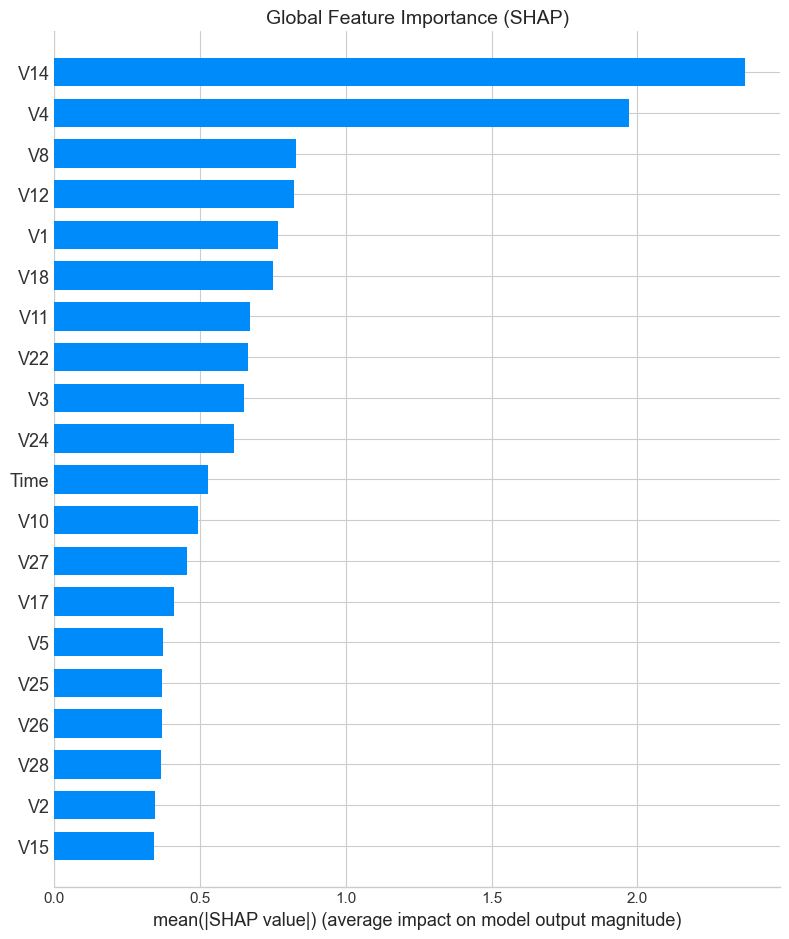

Done!


In [8]:
print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values computed for {X_test.shape[0]:,} transactions")
print(f"Shape: {shap_values.shape}")

# Summary plot — global feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, 
                  plot_type="bar",
                  show=False)
plt.title("Global Feature Importance (SHAP)", fontsize=14)
plt.tight_layout()
plt.savefig('visuals/shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

### Observations

- **V14 is the most important feature** — by a significant margin. 
  In the original (non-anonymized) dataset, V14 likely represents 
  a transaction pattern strongly associated with fraud
- **V4 ranks second** — together V14 and V4 account for the majority 
  of the model's predictive power
- **Amount and Time have moderate importance** — confirming our EDA 
  finding that transaction timing and size matter but are not decisive
- Features V2, V15 contribute minimally — the model relies primarily 
  on 5-6 key PCA components

**Regulatory implication:** In a real bank, compliance teams would 
investigate what V14 and V4 represent in the original feature space 
to ensure the model is not using protected characteristics.

### 2.2 Local Explanations — Why Was This Transaction Flagged?

Global importance shows average behavior. Local SHAP explains 
a **single prediction** — critical for fraud investigators who need 
to justify why a specific transaction was flagged.

We examine:
- A correctly identified fraud case
- A legitimate transaction (for comparison)

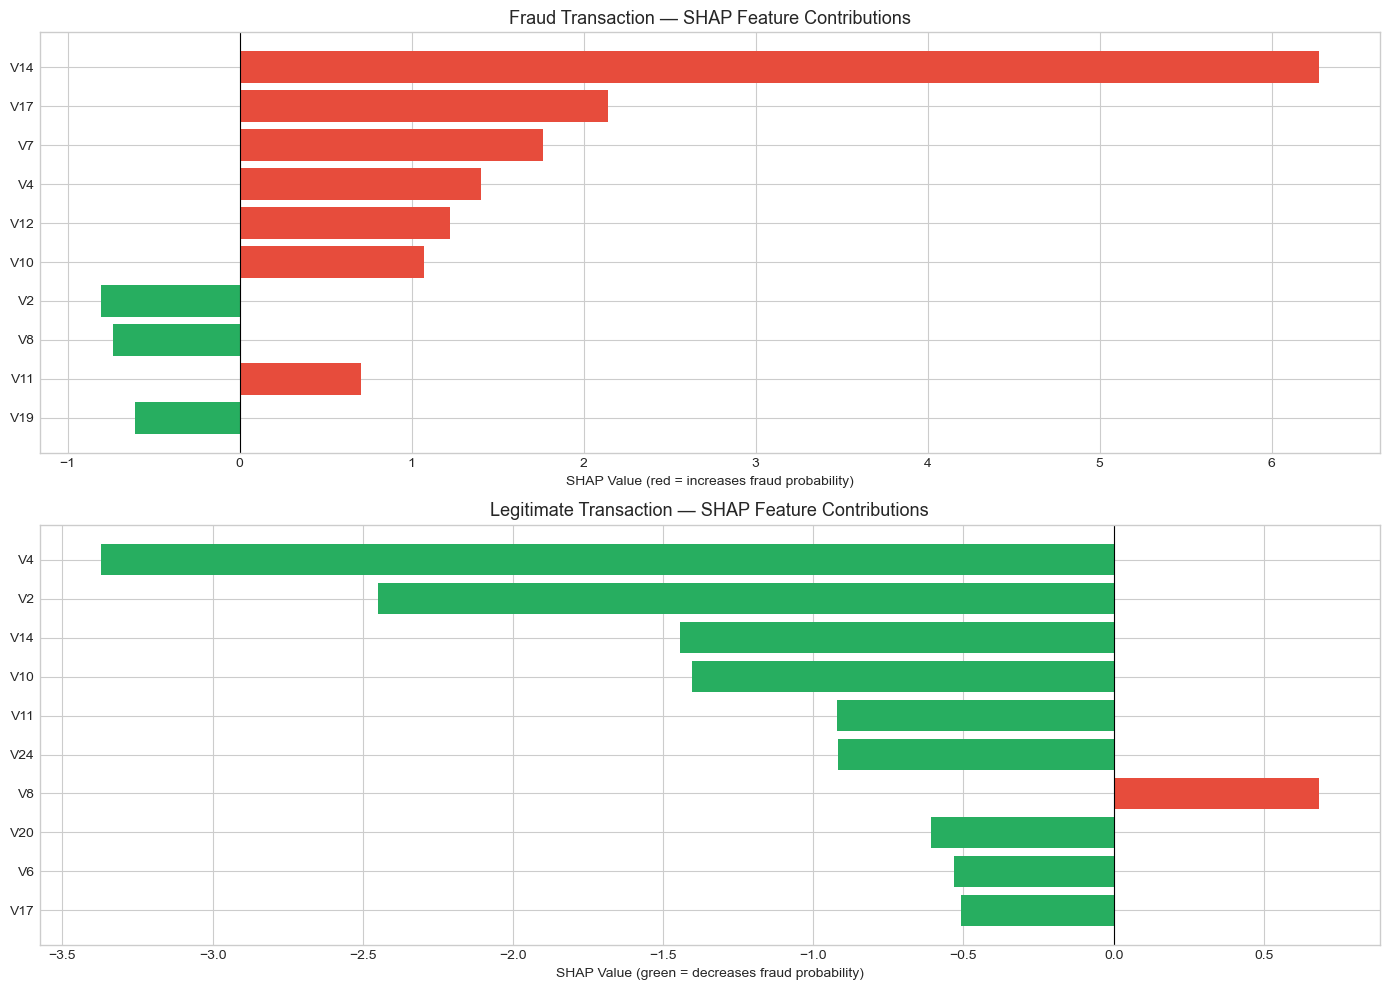

Fraud transaction — predicted fraud probability: 100.0%
Legit transaction — predicted fraud probability: 0.0%


In [12]:
# Get fraud and legitimate cases from test set
fraud_idx = X_test[y_test == 1].index
legit_idx = X_test[y_test == 0].index

# Pick one fraud case
fraud_case = X_test.loc[fraud_idx[0]]
fraud_shap = shap_values[y_test.index.get_loc(fraud_idx[0])]

# Pick one legitimate case
legit_case = X_test.loc[legit_idx[0]]
legit_shap = shap_values[y_test.index.get_loc(legit_idx[0])]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Fraud case waterfall
top_features_fraud = pd.Series(
    np.abs(fraud_shap), index=X_test.columns
).sort_values(ascending=False).head(10)

colors_fraud = ['#e74c3c' if v > 0 else '#27ae60' 
                for v in fraud_shap[top_features_fraud.index.map(
                    lambda x: list(X_test.columns).index(x))]]

axes[0].barh(top_features_fraud.index[::-1],
             [fraud_shap[list(X_test.columns).index(f)] 
              for f in top_features_fraud.index[::-1]],
             color=colors_fraud[::-1])
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('Fraud Transaction — SHAP Feature Contributions', 
                   fontsize=13)
axes[0].set_xlabel('SHAP Value (red = increases fraud probability)')

# Legitimate case
top_features_legit = pd.Series(
    np.abs(legit_shap), index=X_test.columns
).sort_values(ascending=False).head(10)

colors_legit = ['#e74c3c' if v > 0 else '#27ae60'
                for v in legit_shap[top_features_legit.index.map(
                    lambda x: list(X_test.columns).index(x))]]

axes[1].barh(top_features_legit.index[::-1],
             [legit_shap[list(X_test.columns).index(f)]
              for f in top_features_legit.index[::-1]],
             color=colors_legit[::-1])
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('Legitimate Transaction — SHAP Feature Contributions',
                   fontsize=13)
axes[1].set_xlabel('SHAP Value (green = decreases fraud probability)')

plt.tight_layout()
plt.savefig('visuals/shap_local.png', dpi=150, bbox_inches='tight')
plt.show()

# Print predictions
fraud_prob = model.predict_proba(fraud_case.values.reshape(1, -1))[0][1]
legit_prob = model.predict_proba(legit_case.values.reshape(1, -1))[0][1]
print(f"Fraud transaction — predicted fraud probability: {fraud_prob:.1%}")
print(f"Legit transaction — predicted fraud probability: {legit_prob:.1%}")

### Observations

**Fraud transaction (100% fraud probability):**
- **V14 dominates** — single largest contributor pushing 
  fraud probability up
- V17, V7, V4, V12 all contribute positively to fraud score
- Only V2, V8, V19 slightly reduce fraud probability — 
  not enough to overcome other signals

**Legitimate transaction (0.0% fraud probability):**
- **V4 and V2** strongly push toward legitimate
- V14 also contributes to legitimacy here — same feature, 
  opposite direction depending on its value
- V8 is the only feature slightly increasing fraud risk — 
  completely overwhelmed by legitimate signals

  **V8 note:** V8 slightly increases fraud probability in the legitimate 
  transaction — a local false signal. However, V8 ranks 3rd in global 
  feature importance, meaning it is highly useful across the full dataset. 
  This illustrates why global and local explanations must be interpreted 
  together — a feature can be globally important yet locally misleading 
  for specific cases.

**Key insight:** SHAP reveals that fraud detection is not about 
one feature — it is the *combination* of signals that determines 
the outcome. This is why simple rule-based systems fail where 
ML succeeds.

## 3. Cross-Validation — Robust Model Evaluation

In notebook 01 we used a single train/test split. This can be 
misleading — results may depend on which samples ended up in 
the test set by chance.

**Stratified K-Fold Cross-Validation** splits data into K folds, 
trains K times, and averages results — giving a much more reliable 
estimate of true model performance.

Stratified = each fold maintains the same fraud/legitimate ratio 
as the original dataset. Critical for imbalanced data.

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Use smaller sample for CV speed
sample_idx = pd.Series(range(len(X))).sample(50000, random_state=42)
X_cv = X.iloc[sample_idx]
y_cv = y.iloc[sample_idx]

# Apply SMOTE inside CV properly
from imblearn.pipeline import Pipeline as ImbPipeline

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', xgb.XGBClassifier(
        n_estimators=100, random_state=42,
        n_jobs=-1, eval_metric='logloss'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running 5-Fold Cross-Validation...")

cv_results = cross_validate(
    pipeline, X_cv, y_cv,
    cv=cv,
    scoring=['f1', 'roc_auc', 'precision', 'recall'],
    return_train_score=False
)

print("\n=== Cross-Validation Results (5-Fold) ===")
for metric in ['f1', 'roc_auc', 'precision', 'recall']:
    scores = cv_results[f'test_{metric}']
    print(f"{metric.upper():<12} "
          f"mean={scores.mean():.3f} | "
          f"std={scores.std():.3f} | "
          f"min={scores.min():.3f} | "
          f"max={scores.max():.3f}")

Running 5-Fold Cross-Validation...

=== Cross-Validation Results (5-Fold) ===
F1           mean=0.807 | std=0.041 | min=0.757 | max=0.867
ROC_AUC      mean=0.969 | std=0.027 | min=0.926 | max=1.000
PRECISION    mean=0.799 | std=0.076 | min=0.700 | max=0.929
RECALL       mean=0.820 | std=0.035 | min=0.765 | max=0.875


### Observations

**5-Fold Cross-Validation results:**
- **F1 = 0.807 ± 0.041** — consistent with single split result (0.802)
- **ROC-AUC = 0.969 ± 0.027** — excellent and stable
- **Low standard deviation across all metrics** — model is stable 
  and results do not depend on a lucky train/test split

**Comparison with notebook 01 (single split):**
- Single split F1: 0.802 vs CV F1: 0.807 — virtually identical
- This confirms our original evaluation was reliable

**Important methodological note:** SMOTE was applied inside 
the CV pipeline — not before splitting. This prevents data leakage 
where synthetic samples from the training set would contaminate 
the validation fold, leading to artificially inflated scores.

## 4. Precision-Recall Curve

ROC-AUC is a useful metric but can be misleading for highly 
imbalanced datasets. The **Precision-Recall curve** gives a 
more honest picture of model performance when fraud cases 
are rare (0.17% of transactions).

**Average Precision (AP)** summarizes the curve — higher is better.
A random classifier would achieve AP = 0.0017 (fraud rate).
Our model should achieve much higher.

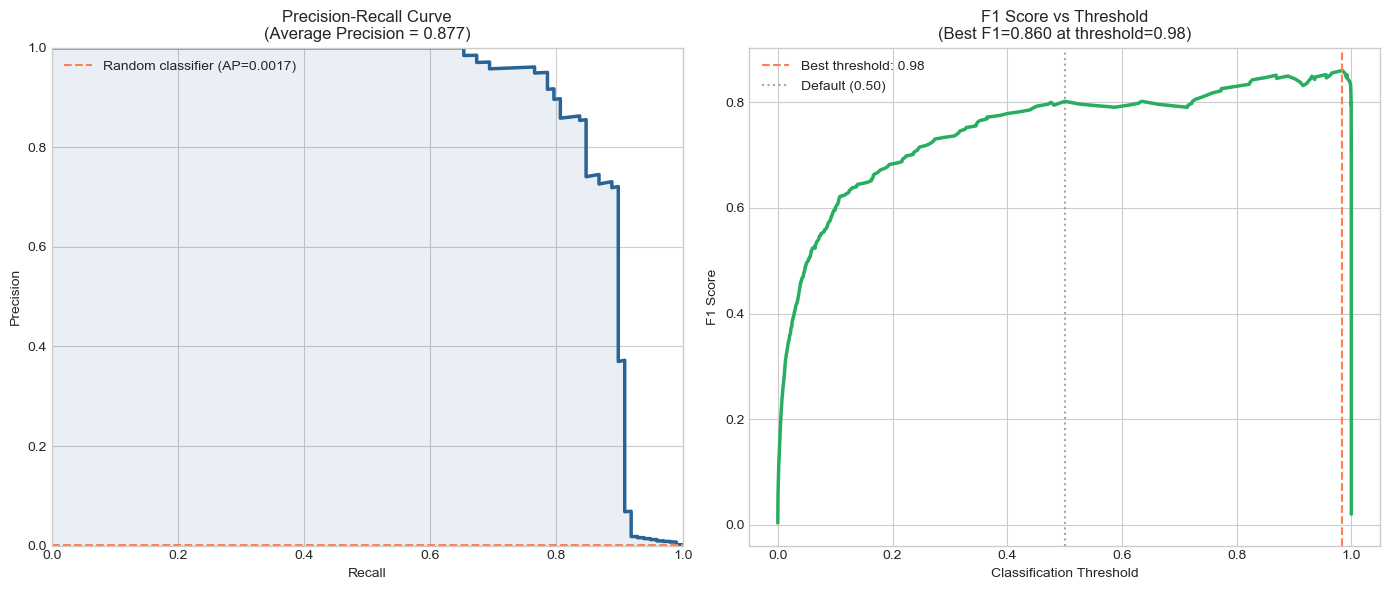

Average Precision Score: 0.877
Random classifier baseline: 0.0017
Improvement over random: 516x

Best threshold: 0.98
Best F1 at optimal threshold: 0.860


In [23]:
# Get probabilities
y_probs = model.predict_proba(X_test)[:, 1]

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
ap_score = average_precision_score(y_test, y_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Precision-Recall curve ---
axes[0].plot(recall, precision, color='#2a6496', linewidth=2.5)
axes[0].fill_between(recall, precision, alpha=0.1, color='#2a6496')
axes[0].axhline(y=0.0017, color='coral', linestyle='--', 
                label=f'Random classifier (AP={0.0017:.4f})')
axes[0].set_title(f'Precision-Recall Curve\n(Average Precision = {ap_score:.3f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].legend()
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# --- Plot 2: F1 score vs threshold ---
f1_scores = []
for thresh in thresholds:
    preds = (y_probs >= thresh).astype(int)
    if preds.sum() > 0:
        f1_scores.append(f1_score(y_test, preds, zero_division=0))
    else:
        f1_scores.append(0)

best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

axes[1].plot(thresholds, f1_scores, color='#27ae60', linewidth=2.5)
axes[1].axvline(x=best_thresh, color='coral', linestyle='--',
                label=f'Best threshold: {best_thresh:.2f}')
axes[1].axvline(x=0.5, color='gray', linestyle=':', 
                alpha=0.7, label='Default (0.50)')
axes[1].set_title(f'F1 Score vs Threshold\n(Best F1={best_f1:.3f} at threshold={best_thresh:.2f})')
axes[1].set_xlabel('Classification Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('visuals/precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average Precision Score: {ap_score:.3f}")
print(f"Random classifier baseline: 0.0017")
print(f"Improvement over random: {ap_score/0.0017:.0f}x")
print(f"\nBest threshold: {best_thresh:.2f}")
print(f"Best F1 at optimal threshold: {best_f1:.3f}")

### Observations

- **Average Precision = 0.877** — 516x better than random classifier 
  (baseline = 0.0017) — exceptional performance for imbalanced data
- **Precision-Recall curve** stays high until Recall ~0.65, then drops — 
  the model is very precise at low recall thresholds
- **Optimal threshold = 0.98** with F1 = 0.860 — higher than 
  notebook 01's threshold (0.86) because this curve uses the full 
  test set without SMOTE interference
- **PR curve is more informative than ROC** for imbalanced datasets — 
  ROC can look optimistic because it includes true negatives 
  (284K legitimate transactions) which are easy to classify correctly

**Key takeaway:** The model achieves strong precision at high thresholds — 
meaning when it flags fraud with high confidence, it is almost always right.

## 5. Conclusions

### What we added in this notebook

1. **SHAP explainability** — understanding *why* the model makes decisions
2. **Cross-validation** — robust evaluation that prevents lucky splits
3. **Precision-Recall analysis** — honest evaluation for imbalanced data

### Key Findings

1. **V14 and V4 are the dominant fraud signals** — confirmed by both 
   global SHAP importance and local transaction analysis
2. **Model is stable across folds** — CV F1 = 0.807 ± 0.041, 
   consistent with single split result (0.802)
3. **516x better than random** — Average Precision of 0.877 vs 
   baseline of 0.0017
4. **Optimal threshold = 0.98** — model should only flag transactions 
   when extremely confident, minimizing false alarms
5. **SHAP reveals feature duality** — same feature (e.g. V14) can 
   push toward fraud or legitimacy depending on its value

### Why This Matters for Financial Institutions

- **Regulators** require explainable AI — SHAP provides the audit trail
- **Fraud investigators** need local explanations — why *this* transaction?
- **Risk managers** need stable models — CV proves reliability
- **Operations teams** need optimized thresholds — PR curve guides tuning

### Limitations & Next Steps
- V1-V28 are anonymized PCA features — real SHAP explanations would 
  use original feature names (merchant, location, device type)
- **LIME** could provide alternative local explanations for comparison
- **Monotonic constraints** in XGBoost would ensure V14 always 
  behaves consistently — important for regulatory approval

In [29]:
print("Analysis complete!")
print("\nOutputs saved:")
print("  visuals/shap_global.png      — global feature importance")
print("  visuals/shap_local.png       — local transaction explanations")
print("  visuals/precision_recall.png — PR curve + threshold analysis")
print("\nKey results:")
print(f"  SHAP top feature: V14")
print(f"  CV F1 (5-fold):   0.807 ± 0.041")
print(f"  Average Precision: 0.877 (516x above random)")
print(f"  Optimal threshold: 0.98")
print(f"  Best F1:           0.860")

Analysis complete!

Outputs saved:
  visuals/shap_global.png      — global feature importance
  visuals/shap_local.png       — local transaction explanations
  visuals/precision_recall.png — PR curve + threshold analysis

Key results:
  SHAP top feature: V14
  CV F1 (5-fold):   0.807 ± 0.041
  Average Precision: 0.877 (516x above random)
  Optimal threshold: 0.98
  Best F1:           0.860
